# Stock vs Index (Alpha)

---

## Importing libraries

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

---

## Cleaning data

In [2]:
tickers = ['HDFCBANK.NS', 'ICICIBANK.NS', '^NSEBANK']
data = yf.download(tickers, period = "10y", auto_adjust=True)
data_dropped = data[~(data == 0).any(axis=1)].copy()
data_dropped = data_dropped[~data_dropped.isna().any(axis=1)].copy()
data_cleaned = data_dropped.copy()
data_cleaned['Volume'] = data_cleaned['Volume'].astype('float64').copy()

[*********************100%***********************]  3 of 3 completed


---

## Calculating alpha

### Calculating beta (sensitivity)

In [3]:
data_close = data_cleaned['Close'].copy()
returns = data_close.pct_change().dropna()

def beta(stock, index):
    matrix = np.cov(stock, index)
    return matrix[0, 1] / matrix[1, 1]

beta_hdfc = beta(returns["HDFCBANK.NS"], returns["^NSEBANK"])
beta_icici = beta(returns["ICICIBANK.NS"], returns["^NSEBANK"])

print(f"HDFC Bank Beta: {beta_hdfc:.3f} | ICICI Bank Beta: {beta_icici:.3f}")

HDFC Bank Beta: 0.953 | ICICI Bank Beta: 1.077


### Calculating alpha using beta

In [4]:
tickers_bank = ['HDFCBANK.NS', 'ICICIBANK.NS']
index = '^NSEBANK'

rf = 0.0675 # 10 years G-Sec Yield (6.75%)

# Calculate Annualized Returns
annual_returns = (1 + returns.mean())**252 - 1
market_return = annual_returns[index]

betas = {"HDFCBANK.NS": beta_hdfc, "ICICIBANK.NS": beta_icici}
# 4. Calculate Alpha (Jensen's Alpha)
alpha_results = {}
for t in tickers_bank:
    expected_return = rf + betas[t] * (market_return - rf)
    alpha = annual_returns[t] - expected_return
    alpha_results[t] = alpha

print(f"HDFC Alpha: {alpha_results['HDFCBANK.NS']:.2%}")
print(f"ICICI Alpha: {alpha_results['ICICIBANK.NS']:.2%}")

HDFC Alpha: 1.80%
ICICI Alpha: 16.04%


---

## Plotting alpha

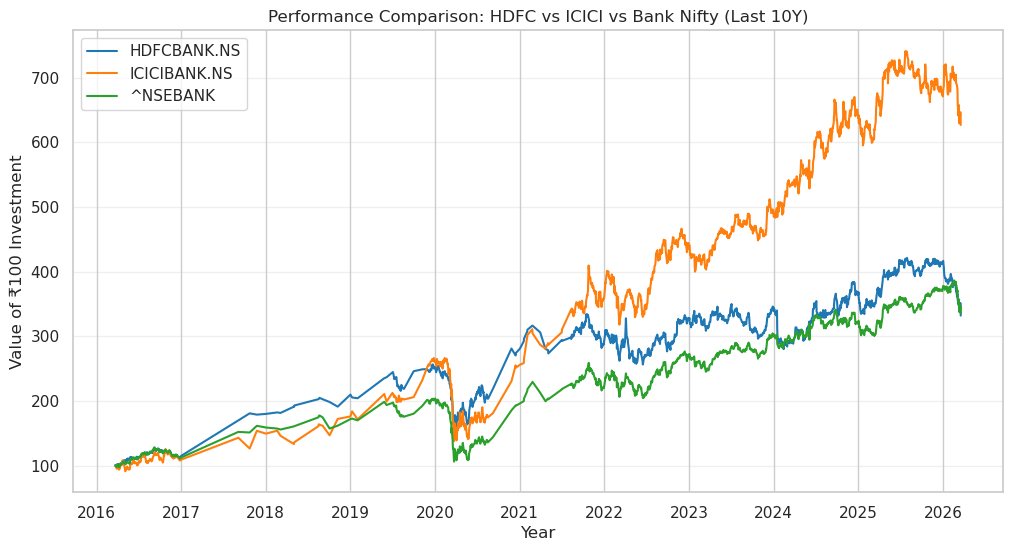

In [6]:
# Normalize data to start at 100 (Cumulative Returns)
normalized_df = (1 + returns).cumprod() * 100

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.lineplot(data=normalized_df, palette="tab10", linewidth=1.5, dashes=False)
plt.title("Performance Comparison: HDFC vs ICICI vs Bank Nifty (Last 10Y)")
plt.xlabel("Year")
plt.ylabel("Value of ₹100 Investment")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

---